# 03 — Causal Inference & Financial Assessment

Steps in this notebook:

| Step | Description |
|---|---|
| 3.1 | Naive churn comparison (biased — for context) |
| 3.2 | Confounder-adjusted logistic regression (`statsmodels`) |
| 3.3 | Average Marginal Effect (AME) of `has_booster` |
| 3.4 | Financial assessment & CCO recommendation |

**Input:** `processed/df_analysis.parquet`

## Setup

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [13]:
df = pd.read_csv(Path("processed/df_analysis.csv"))

# Restore ordered categorical (CSV loses dtype)
df["internet_usage"] = pd.Categorical(
    df["internet_usage"],
    categories=["Low", "Medium", "High", "Extreme"],
    ordered=True,
)
for col in ["commune", "gender", "tv_product", "mobile_product", "zip"]:
    df[col] = df[col].astype("category")

print(f"Loaded {len(df):,} rows")

Loaded 125,000 rows


---
## 3.1 — Naive Analysis (Biased Baseline)

Raw churn rates ignoring all confounders. Shown for transparency and to contrast
with the adjusted result.

In [3]:
naive = (
    df.groupby("has_booster", as_index=False)["churned"]
      .mean()
      .rename(columns={"churned": "churn_rate"})
)
naive["churn_rate_pct"] = (naive["churn_rate"] * 100).round(2)
naive["group"] = naive["has_booster"].map({0: "No Booster", 1: "Has Booster"})

p1 = naive.loc[naive["has_booster"] == 1, "churn_rate"].iloc[0]
p0 = naive.loc[naive["has_booster"] == 0, "churn_rate"].iloc[0]
delta_naive_pp = (p1 - p0) * 100

display(naive[["group", "churn_rate_pct"]])
print(f"\nNaive churn gap (Booster − No Booster): {delta_naive_pp:+.2f} pp")
print("⚠  This estimate is BIASED due to self-selection. Do not report to CCO.")

,group,churn_rate_pct
0,No Booster,14.53
1,Has Booster,12.51



Naive churn gap (Booster − No Booster): -2.02 pp
⚠  This estimate is BIASED due to self-selection. Do not report to CCO.


---
## Step 4 — Causal Inference (Triangulation with 2 Methods)

We estimate the booster impact using two complementary methods:

1. **Model 1: Interaction Logit + AME**
Causal model for churn with heterogeneous treatment effect via `has_booster * internet_usage`.

2. **Model 2: Propensity Score Matching (PSM) / "Digital Twins"**
Each treated customer is paired with a statistically similar untreated customer using propensity scores.

If both methods tell a similar story, confidence in the business decision increases.

In [15]:
# Use confounders requested in the prompt
model_cols = [
    "churned", "has_booster", "age", "tenure",
    "internet_usage", "tv_product", "mobile_product", "commune",
]
df_clean = df[model_cols].dropna().copy()

# Ensure stable category ordering for interaction interpretation
df_clean["internet_usage"] = pd.Categorical(
    df_clean["internet_usage"],
    categories=["Low", "Medium", "High", "Extreme"],
    ordered=True,
 )
for col in ["tv_product", "mobile_product", "commune"]:
    df_clean[col] = df_clean[col].astype("category")

print(f"Rows for causal modeling: {len(df_clean):,} ({len(df_clean)/len(df):.1%} of total)")
print("Internet usage mix:")
display((df_clean["internet_usage"].value_counts(normalize=True).sort_index() * 100).round(2).rename("pct"))

Rows for causal modeling: 125,000 (100.0% of total)
Internet usage mix:


internet_usage
Low        23.58
Medium     32.12
High       27.75
Extreme    16.56
Name: pct, dtype: float64

In [16]:
# Model 1: interaction logit to capture heterogeneous effect by usage tier
formula_interaction = (
    "churned ~ has_booster * C(internet_usage) + age + tenure + "
    "C(tv_product) + C(mobile_product) + C(commune)"
 )

logit_interaction = smf.logit(formula=formula_interaction, data=df_clean).fit(disp=False)
print(logit_interaction.summary())

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:               125000
Model:                          Logit   Df Residuals:                   124983
Method:                           MLE   Df Model:                           16
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.01244
Time:                        16:09:07   Log-Likelihood:                -50272.
converged:                       True   LL-Null:                       -50905.
Covariance Type:            nonrobust   LLR p-value:                9.225e-260
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -1.9138      0.042    -45.631      0.000      -1.996      -1.832
C(internet_usage)[T.Medium]              

### Model 1 — Interaction Logit Margins (Overall + Tier-specific)

To keep interpretation business-friendly, we compute treatment effects on probability scale:

$$
\Delta_i = \hat{P}(\text{churn}=1\mid T=1,X_i)-\hat{P}(\text{churn}=1\mid T=0,X_i)
$$

Then average overall and within each `internet_usage` tier (our AME-style marginal effects).

### Model 2 — PSM "Digital Twins" ATT

1. Fit a propensity model for treatment (`has_booster`).
2. Match each treated customer to nearest untreated customer by propensity score (with caliper).
3. Compute ATT overall and by usage tier.

In [20]:
# --- Model 1 Margins / AME with heterogeneity ---
df_t1 = df_clean.copy()
df_t0 = df_clean.copy()
df_t1["has_booster"] = 1
df_t0["has_booster"] = 0

# G-computation: individual treatment effect on churn probability
p1 = logit_interaction.predict(df_t1)
p0 = logit_interaction.predict(df_t0)
df_clean["ite_churn"] = p1 - p0

# Overall AME of booster on churn probability
ame_overall = float(df_clean["ite_churn"].mean())

# Tier-specific effects
tier_effects = (
    df_clean.groupby("internet_usage", observed=True)["ite_churn"]
            .agg(["mean", "count", "std"])
)
tier_effects["se"] = tier_effects["std"] / np.sqrt(tier_effects["count"])
tier_effects["ci_low"] = tier_effects["mean"] - 1.96 * tier_effects["se"]
tier_effects["ci_high"] = tier_effects["mean"] + 1.96 * tier_effects["se"]

# Keep old downstream variable name for compatibility
ame_booster_pp = ame_overall

tier_effects_display = (
    tier_effects.reset_index()
        .assign(
            mean_pp=lambda d: d["mean"] * 100,
            ci_low_pp=lambda d: d["ci_low"] * 100,
            ci_high_pp=lambda d: d["ci_high"] * 100,
        )[["internet_usage", "count", "mean_pp", "ci_low_pp", "ci_high_pp"]]
        .rename(columns={
            "internet_usage": "usage_tier",
            "count": "n_customers",
            "mean_pp": "booster_effect_pp",
        })
)

print("=" * 72)
print("MODEL 1: Interaction Logit Margins")
print("=" * 72)
print(f"Overall AME of booster on churn: {ame_overall*100:+.2f} pp")
print("(Negative means churn reduction)")
print("\nTier-specific booster effects (on churn probability):")
display(
    tier_effects_display.style.format({
        "booster_effect_pp": "{:+.2f}",
        "ci_low_pp": "{:+.2f}",
        "ci_high_pp": "{:+.2f}",
        "n_customers": "{:,.0f}",
    })
)

MODEL 1: Interaction Logit Margins
Overall AME of booster on churn: -0.97 pp
(Negative means churn reduction)

Tier-specific booster effects (on churn probability):


,usage_tier,n_customers,booster_effect_pp,ci_low_pp,ci_high_pp
0,Low,"29,469",-0.18,-0.18,-0.18
1,Medium,"40,145",+0.49,+0.49,+0.49
2,High,"34,687",+0.01,+0.01,+0.01
3,Extreme,"20,699",-6.57,-6.58,-6.55


In [21]:
# --- Model 2: Propensity Score Matching (Digital Twins) ---
# Propensity model for treatment assignment
ps_formula = (
    "has_booster ~ age + tenure + C(internet_usage) + "
    "C(tv_product) + C(mobile_product) + C(commune)"
 )
ps_model = smf.logit(formula=ps_formula, data=df_clean).fit(disp=False)
df_clean["propensity_score"] = ps_model.predict(df_clean)

treated = df_clean[df_clean["has_booster"] == 1].copy()
control = df_clean[df_clean["has_booster"] == 0].copy()

# 1:1 nearest-neighbor match on propensity score
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])
distances, idx = nn.kneighbors(treated[["propensity_score"]])

treated = treated.reset_index(drop=True)
matched_controls = control.iloc[idx.flatten()].reset_index(drop=True)
treated["match_distance"] = distances.flatten()

# Caliper to avoid poor-quality matches
caliper = 0.02
keep = treated["match_distance"] <= caliper

matched = pd.DataFrame({
    "treated_churn": treated.loc[keep, "churned"].to_numpy(),
    "control_churn": matched_controls.loc[keep, "churned"].to_numpy(),
    "internet_usage": treated.loc[keep, "internet_usage"].astype(str).to_numpy(),
    "treated_ps": treated.loc[keep, "propensity_score"].to_numpy(),
    "control_ps": matched_controls.loc[keep, "propensity_score"].to_numpy(),
    "match_distance": treated.loc[keep, "match_distance"].to_numpy(),
})
matched["pair_effect"] = matched["treated_churn"] - matched["control_churn"]

att_overall = float(matched["pair_effect"].mean())
att_by_tier = (
    matched.groupby("internet_usage", as_index=False)["pair_effect"]
           .agg(att="mean", n_pairs="count")
           .sort_values("internet_usage")
)

print("=" * 72)
print("MODEL 2: PSM Digital Twins")
print("=" * 72)
print(f"Treated customers: {len(treated):,}")
print(f"Matched pairs within caliper {caliper:.3f}: {len(matched):,} ({len(matched)/len(treated):.1%} coverage)")
print(f"Average propensity distance in matched pairs: {matched['match_distance'].mean():.4f}")
print(f"\nDigital Twins ATT on churn: {att_overall*100:+.2f} pp")
print("(Negative means the booster lowers churn for treated customers)")

print("\nDigital Twins ATT by usage tier:")
display(
    att_by_tier.assign(att_pp=lambda d: d["att"] * 100)
               [["internet_usage", "n_pairs", "att_pp"]]
               .rename(columns={"internet_usage": "usage_tier", "att_pp": "att_pp"})
               .style.format({"n_pairs": "{:,.0f}", "att_pp": "{:+.2f}"})
)

# Quick triangulation view
triangulation = pd.DataFrame({
    "method": ["Interaction Logit AME", "PSM Digital Twins ATT"],
    "effect_pp": [ame_overall * 100, att_overall * 100],
})
print("\nTriangulation summary:")
display(triangulation.style.format({"effect_pp": "{:+.2f}"}))

MODEL 2: PSM Digital Twins
Treated customers: 25,000
Matched pairs within caliper 0.020: 25,000 (100.0% coverage)
Average propensity distance in matched pairs: 0.0000

Digital Twins ATT on churn: -1.87 pp
(Negative means the booster lowers churn for treated customers)

Digital Twins ATT by usage tier:


,usage_tier,n_pairs,att_pp
0,Extreme,"7,854",-4.74
1,High,"8,382",-0.18
2,Low,"2,518",-1.31
3,Medium,"6,246",-0.75



Triangulation summary:


,method,effect_pp
0,Interaction Logit AME,-0.97
1,PSM Digital Twins ATT,-1.87


---
## Step 5 — Segmented Financial Business Case

Use tier-level causal impact from **Model 1 margins** to compare:

1. **Blanket rollout** to all 1.5M customers.
2. **Targeted rollout** to High + Extreme usage tiers only.

For each scenario:

$$
\text{Net ROI} = \text{Revenue Saved from Prevented Churn} - \text{Rollout Cost}
$$

In [24]:
N_CUSTOMERS_TOTAL         = 1_500_000
VALUE_PER_PREVENTED_CHURN = 1_800.0
BOOSTER_COST              = 35.0

# Convert Model 1 tier effects to prevented churn rates (positive is good)
tier_fin = tier_effects.copy()
tier_fin["prevented_rate"] = (-tier_fin["mean"]).clip(lower=0.0)

# Extrapolate population mix from observed sample
tier_mix = df_clean["internet_usage"].value_counts(normalize=True).sort_index()
tier_fin["mix"] = tier_mix
tier_fin["population"] = tier_fin["mix"] * N_CUSTOMERS_TOTAL

# Revenue and cost per tier for rollout
tier_fin["revenue_saved_chf"] = tier_fin["population"] * tier_fin["prevented_rate"] * VALUE_PER_PREVENTED_CHURN
tier_fin["cost_chf"] = tier_fin["population"] * BOOSTER_COST
tier_fin["net_roi_chf"] = tier_fin["revenue_saved_chf"] - tier_fin["cost_chf"]

# Scenario 1: Blanket rollout
blanket_cost = float(tier_fin["cost_chf"].sum())
blanket_saved = float(tier_fin["revenue_saved_chf"].sum())
blanket_net = blanket_saved - blanket_cost

# Scenario 2: Targeted rollout (High + Extreme)
target_tiers = ["High", "Extreme"]
targeted = tier_fin.loc[target_tiers].copy()
target_cost = float(targeted["cost_chf"].sum())
target_saved = float(targeted["revenue_saved_chf"].sum())
target_net = target_saved - target_cost

print("=" * 78)
print("STEP 5: C-LEVEL ROI SUMMARY (USING MODEL 1 TIER MARGINS)")
print("=" * 78)
print("\nBlanket rollout (All usage tiers):")
print(f"  Cost of rollout                       : CHF {blanket_cost:,.0f}")
print(f"  Revenue saved from prevented churn    : CHF {blanket_saved:,.0f}")
print(f"  Net profit / (loss)                   : CHF {blanket_net:,.0f}")

print("\nTargeted rollout (High + Extreme only):")
print(f"  Cost of targeted rollout              : CHF {target_cost:,.0f}")
print(f"  Revenue saved from prevented churn    : CHF {target_saved:,.0f}")
print(f"  Net profit / (loss)                   : CHF {target_net:,.0f}")

delta_vs_blanket = target_net - blanket_net
print("\nBusiness takeaway:")
print(f"  Targeted vs Blanket uplift in net profit: CHF {delta_vs_blanket:,.0f}")

if target_net > 0 and target_net > blanket_net:
    print("  Recommendation: pursue Targeted rollout first; it is the superior value strategy.")
elif blanket_net > 0 and blanket_net >= target_net:
    print("  Recommendation: Blanket rollout is financially viable and at least as good as Targeted.")
else:
    print("  Recommendation: avoid universal rollout; use strict targeting or pilot tests.")

print("\nTier-level economics used in decision:")
display(
    tier_fin.reset_index().rename(columns={"internet_usage": "usage_tier"})
           [["usage_tier", "population", "prevented_rate", "revenue_saved_chf", "cost_chf", "net_roi_chf"]]
           .assign(prevented_rate_pp=lambda d: d["prevented_rate"] * 100)
           [["usage_tier", "population", "prevented_rate_pp", "revenue_saved_chf", "cost_chf", "net_roi_chf"]]
           .style.format({
               "population": "{:,.0f}",
               "prevented_rate_pp": "{:.2f}",
               "revenue_saved_chf": "CHF {:,.0f}",
               "cost_chf": "CHF {:,.0f}",
               "net_roi_chf": "CHF {:,.0f}",
           })
)

STEP 5: C-LEVEL ROI SUMMARY (USING MODEL 1 TIER MARGINS)

Blanket rollout (All usage tiers):
  Cost of rollout                       : CHF 52,500,000
  Revenue saved from prevented churn    : CHF 30,536,116
  Net profit / (loss)                   : CHF -21,963,884

Targeted rollout (High + Extreme only):
  Cost of targeted rollout              : CHF 23,262,120
  Revenue saved from prevented churn    : CHF 29,363,488
  Net profit / (loss)                   : CHF 6,101,368

Business takeaway:
  Targeted vs Blanket uplift in net profit: CHF 28,065,251
  Recommendation: pursue Targeted rollout first; it is the superior value strategy.

Tier-level economics used in decision:


,usage_tier,population,prevented_rate_pp,revenue_saved_chf,cost_chf,net_roi_chf
0,Low,"353,628",0.18,"CHF 1,172,629","CHF 12,376,980","CHF -11,204,351"
1,Medium,"481,740",0.00,CHF 0,"CHF 16,860,900","CHF -16,860,900"
2,High,"416,244",0.00,CHF 0,"CHF 14,568,540","CHF -14,568,540"
3,Extreme,"248,388",6.57,"CHF 29,363,488","CHF 8,693,580","CHF 20,669,908"


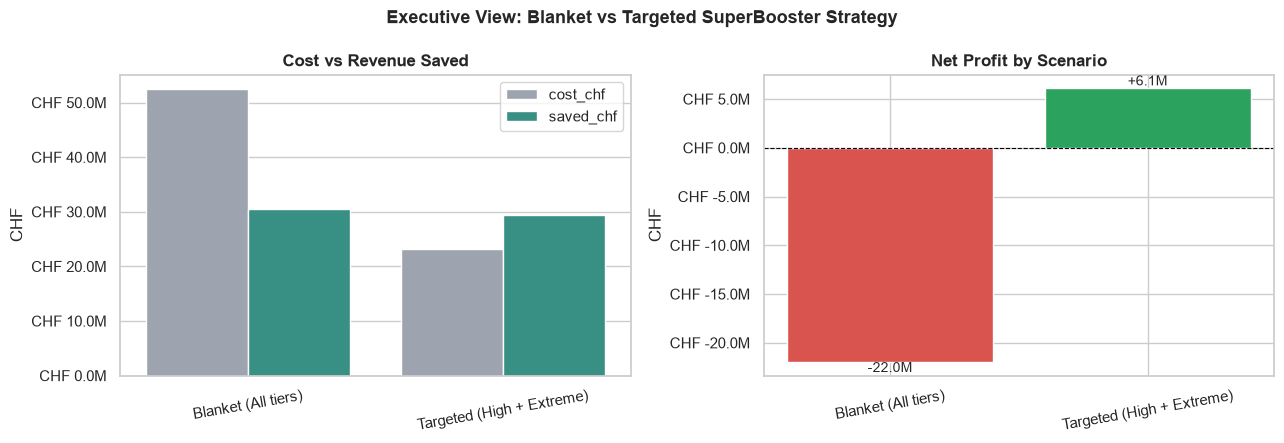

In [23]:
scenario_df = pd.DataFrame({
    "scenario": ["Blanket (All tiers)", "Targeted (High + Extreme)"],
    "cost_chf": [blanket_cost, target_cost],
    "saved_chf": [blanket_saved, target_saved],
    "net_chf": [blanket_net, target_net],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: cost vs saved
plot1 = scenario_df.melt(id_vars="scenario", value_vars=["cost_chf", "saved_chf"],
                         var_name="metric", value_name="value")
sns.barplot(data=plot1, x="scenario", y="value", hue="metric", palette=["#9aa4b2", "#2a9d8f"], ax=axes[0])
axes[0].set_title("Cost vs Revenue Saved", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("CHF")
axes[0].tick_params(axis="x", rotation=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
axes[0].legend(title="")

# Right panel: net profit
colors = ["#d9534f" if v < 0 else "#2ca25f" for v in scenario_df["net_chf"]]
bars = axes[1].bar(scenario_df["scenario"], scenario_df["net_chf"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Net Profit by Scenario", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("CHF")
axes[1].tick_params(axis="x", rotation=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
for b, val in zip(bars, scenario_df["net_chf"]):
    axes[1].text(b.get_x() + b.get_width()/2, val, f"{val/1e6:+.1f}M", ha="center",
                 va="bottom" if val >= 0 else "top", fontsize=10)

fig.suptitle("Executive View: Blanket vs Targeted SuperBooster Strategy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()